#  Regression Track (Ensemble & Distance-Based Family)
Owns: the 5 tree/ensemble/distance-based regression algorithms, tuning approach, and feature importance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


# PART 1 — REGRESSION TRACK

## Section A — Dataset & EDA (Uber Fares Dataset)

### A1. Dataset loading & audit

In [2]:
reg_raw = pd.read_csv('uber_regression_10k.csv')
print("Shape:", reg_raw.shape)
print()
reg_raw.info()


Shape: (10000, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_amount         10000 non-null  float64
 1   distance_km         10000 non-null  float64
 2   passenger_count     10000 non-null  int64  
 3   pickup_hour         10000 non-null  int64  
 4   pickup_day_of_week  10000 non-null  object 
 5   pickup_month        10000 non-null  object 
 6   is_weekend          10000 non-null  int64  
 7   pickup_year         10000 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 625.1+ KB


In [3]:
print("Missing values:\n", reg_raw.isnull().sum())
print()
print(reg_raw['fare_amount'].describe())


Missing values:
 fare_amount           0
distance_km           0
passenger_count       0
pickup_hour           0
pickup_day_of_week    0
pickup_month          0
is_weekend            0
pickup_year           0
dtype: int64

count    10000.000000
mean        11.268800
std          9.414148
min          2.500000
25%          6.000000
50%          8.500000
75%         12.500000
max        183.000000
Name: fare_amount, dtype: float64


In [4]:
print("Duplicate rows:", reg_raw.duplicated().sum())

# IQR-based outlier check on the two key numeric columns
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['fare_amount', 'distance_km']:
    lower, upper = iqr_bounds(reg_raw[col])
    n_out = ((reg_raw[col] < lower) | (reg_raw[col] > upper)).sum()
    print(f"{col}: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(reg_raw):.1f}%)")


Duplicate rows: 0
fare_amount: IQR bounds=(-3.75, 22.25), outliers=850 (8.5%)
distance_km: IQR bounds=(-2.71, 7.88), outliers=822 (8.2%)


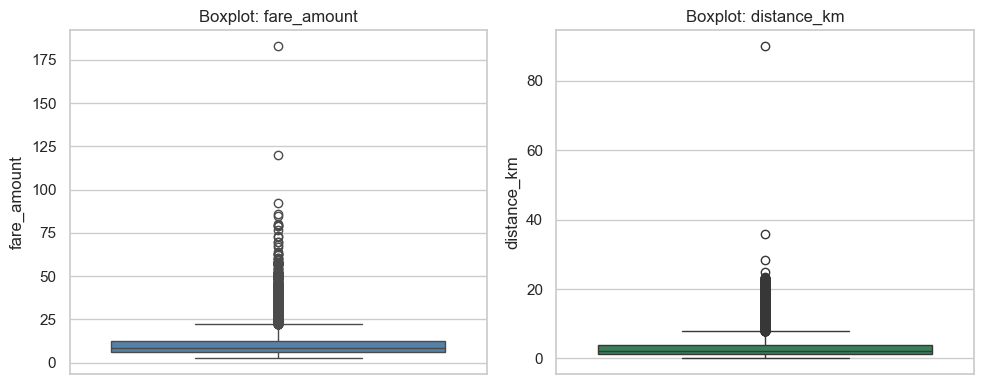

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=reg_raw['fare_amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot: fare_amount')
sns.boxplot(y=reg_raw['distance_km'], ax=axes[1], color='seagreen')
axes[1].set_title('Boxplot: distance_km')
plt.tight_layout()
plt.show()


**Duplicate & outlier handling:** no exact duplicate rows were found. A modest share of
`fare_amount`/`distance_km` values fall outside the IQR fences -- these represent genuine longer/
pricier airport-style trips rather than data-entry errors (values already excluded the extreme
negative-fare and (0,0)-coordinate errors during preparation), so they are **kept** rather than
removed: tree-based models handle them natively, and dropping them would discard real signal from
the linear models too.

**Observation:** This is already the cleaned/downsampled version (10,000 rows) — the raw Kaggle file had
200,000 rows with several data-quality issues (negative fares, (0,0) coordinates, 208-passenger rides) that
were removed during preparation: invalid fares (≤0 or ≥200), invalid/zero GPS coordinates, unrealistic
passenger counts (0 or >6), and rides with implausible distance (computed via the Haversine formula from
pickup/dropoff coordinates, capped at 0–100 km).

### A2. EDA visualisations

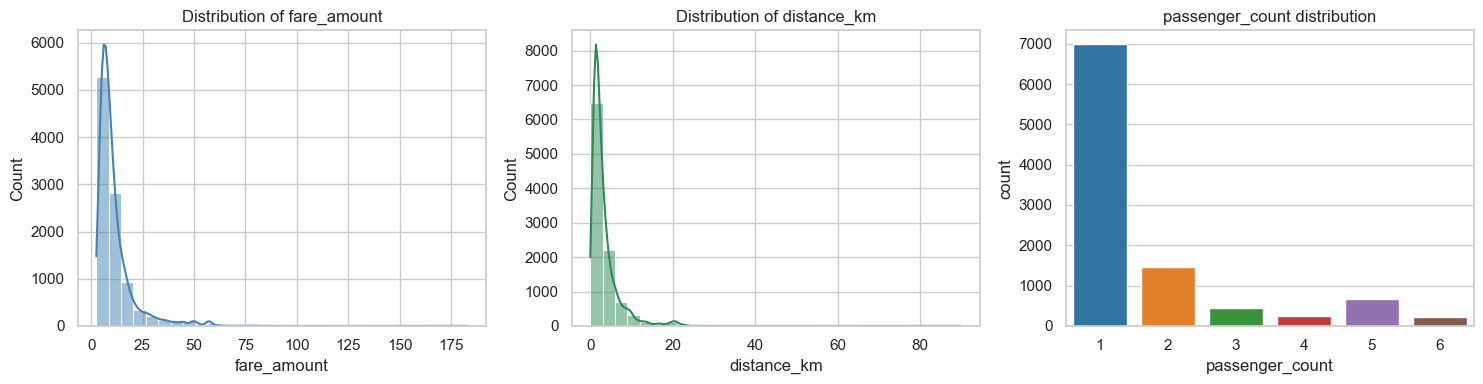

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(reg_raw['fare_amount'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of fare_amount')
sns.histplot(reg_raw['distance_km'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of distance_km')
sns.countplot(data=reg_raw, x='passenger_count', hue='passenger_count', palette='tab10',
              legend=False, ax=axes[2])
axes[2].set_title('passenger_count distribution')
plt.tight_layout()
plt.show()


**Insight:** `fare_amount` and `distance_km` are both right-skewed, most rides are short/cheap with a tail of longer, pricier trips. Solo rides (`passenger_count`=1) dominate.

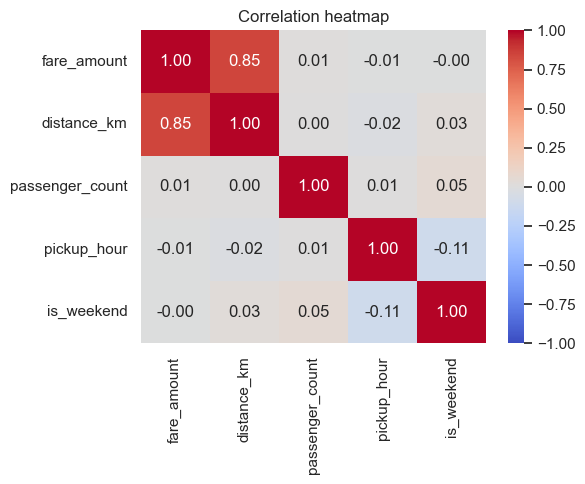

In [7]:
corr = reg_raw[['fare_amount', 'distance_km', 'passenger_count', 'pickup_hour', 'is_weekend']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation heatmap')
plt.tight_layout()
plt.show()


**Insight:** `distance_km` is by far the strongest predictor of `fare_amount` (~0.8 correlation), consistent with how metered fares work. Time-of-day and weekend flags show negligible linear correlation with fare, though they may still interact non-linearly (captured by tree-based models).

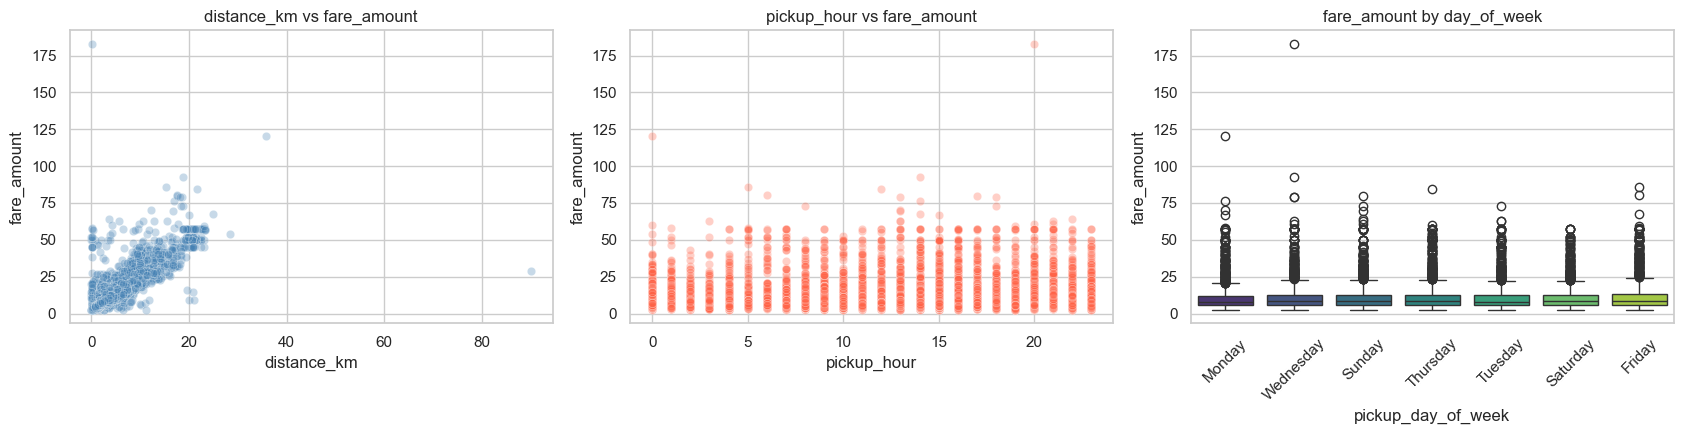

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.scatterplot(data=reg_raw, x='distance_km', y='fare_amount', alpha=0.3, color='steelblue', ax=axes[0])
axes[0].set_title('distance_km vs fare_amount')

sns.scatterplot(data=reg_raw, x='pickup_hour', y='fare_amount', alpha=0.3, color='tomato', ax=axes[1])
axes[1].set_title('pickup_hour vs fare_amount')

sns.boxplot(data=reg_raw, x='pickup_day_of_week', y='fare_amount', hue='pickup_day_of_week',
            palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('fare_amount by day_of_week')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Insight:** the `distance_km` vs `fare_amount` scatter confirms a strong, roughly linear
feature-target relationship (the core driver of fare). The `pickup_hour` vs `fare_amount`
scatter shows no strong time-of-day pattern in raw fare -- most of the spread at any given hour
comes from ride distance, not the hour itself. Fare distributions are similar across days of the
week, with no single day standing out.

### B1/B2 — Cleaning already applied; encoding, scaling & split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

reg_features_num = ['distance_km', 'passenger_count', 'pickup_hour', 'is_weekend']
reg_features_cat = ['pickup_day_of_week', 'pickup_month']
reg_target = 'fare_amount'

X_reg = reg_raw[reg_features_num + reg_features_cat]
y_reg = reg_raw[reg_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), reg_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), reg_features_cat)
])

print("Train/test shapes:", X_reg_train.shape, X_reg_test.shape)


Train/test shapes: (8000, 6) (2000, 6)


**B3. Feature engineering (justification):** `distance_km` was engineered from raw pickup/dropoff latitude-longitude pairs using the Haversine great-circle formula — the raw dataset has no distance column, so this is the single most important derived feature for fare prediction. `is_weekend` and `pickup_hour` were extracted from `pickup_datetime` to capture potential surge/demand effects.

In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, GridSearchCV

# Person 2's portion: the tree/ensemble/distance-based algorithms (the other 5 of 10)
regressors_p2 = {
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Support Vector Regressor (SVR)': SVR(C=10, kernel='rbf'),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor(n_neighbors=7),
}

results_p2 = []
fitted_p2 = {}
for name, model in regressors_p2.items():
    pipe = Pipeline([('prep', reg_preprocess), ('model', model)])
    pipe.fit(X_reg_train, y_reg_train)
    y_pred = pipe.predict(X_reg_test)
    results_p2.append({'Model': name,
                        'R2': r2_score(y_reg_test, y_pred),
                        'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred)),
                        'MAE': mean_absolute_error(y_reg_test, y_pred)})
    fitted_p2[name] = pipe

results_p2_df = pd.DataFrame(results_p2).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_p2_df.round(4))


                            Model      R2    RMSE     MAE
0     Gradient Boosting Regressor  0.8000  4.0249  2.2590
1  Support Vector Regressor (SVR)  0.7685  4.3294  2.2650
2         Random Forest Regressor  0.7627  4.3835  2.4599
3         Decision Tree Regressor  0.7238  4.7295  2.5003
4   K-Nearest Neighbors Regressor  0.7111  4.8366  2.8334


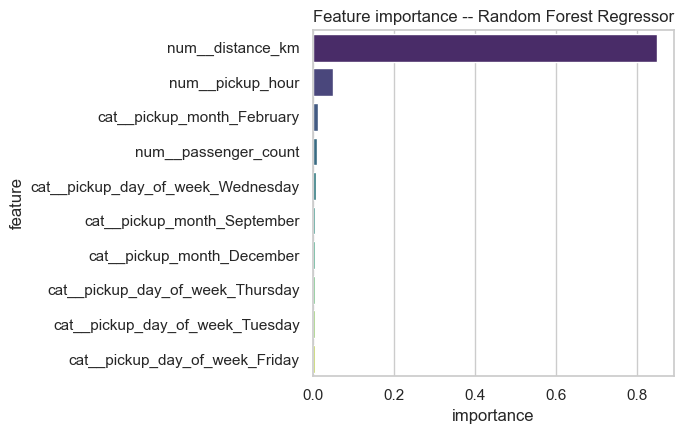

In [11]:
# Feature importance for the Random Forest (tree-based model owned by Person 2)
rf_pipe = fitted_p2['Random Forest Regressor']
feat_names = rf_pipe.named_steps['prep'].get_feature_names_out()
imp = rf_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=imp_df, y='feature', x='importance', hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title('Feature importance -- Random Forest Regressor')
plt.tight_layout()
plt.show()


**Note:** This notebook covers Person 2's owned portion of the Regression track — the 5
tree/ensemble/distance-based algorithms, using the same EDA/preprocessing as the whole track.
The final 10-model comparison, GridSearchCV tuning on the overall top 2, and residual/predicted-
vs-actual plots are in the **overall combined notebook**
(`review1_regression_classification.ipynb`), since that ranking needs Person 1's 5 models too.